In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from keras.models import Sequential
from keras.layers.normalization import BatchNormalization
from keras.layers.advanced_activations import LeakyReLU
from keras.losses import categorical_crossentropy
from keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:519: FutureWarn

In [2]:
train = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_test.csv')

In [3]:
train.shape,test.shape

((60000, 785), (10000, 785))

In [4]:
train.label.nunique()

10

Convert the dataframe into a numpy array of type float32

In [5]:
train = np.array(train,dtype='float32')
test = np.array(test,dtype='float32')
                 
train.shape, test.shape

((60000, 785), (10000, 785))

In [6]:
train_X = train[:,1:] / 255
test_X =  test[:,1:] / 255

train_X = train_X.reshape(train_X.shape[0], 28,28)
test_X = test_X.reshape(test_X.shape[0], 28,28)

train_y = train[:,0]
test_y = test[:,0]


In [7]:
train_X = train_X.reshape(-1, 28,28, 1)
test_X = test_X.reshape(-1, 28,28, 1)

train_Y_one_hot = to_categorical(train_y)
test_Y_one_hot = to_categorical(test_y)

train_X.shape, test_X.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [8]:
X_train,X_valid,y_train,y_valid = train_test_split(train_X,train_Y_one_hot,test_size=0.3)
X_train.shape,X_valid.shape,y_train.shape,y_valid.shape

((42000, 28, 28, 1), (18000, 28, 28, 1), (42000, 10), (18000, 10))

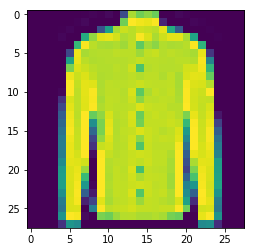

In [9]:
plt.imshow( X_train[5850,:].reshape((28,28)))
plt.show()

CNN Model


model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='linear',input_shape=(28,28,1),padding='same'))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D((2,2),padding='same'))

model.add(Conv2D(64,kernel_size=(3,3),activation='linear',input_shape=(28,28,1),padding='same'))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D((2,2),padding='same'))

model.add(Conv2D(128,kernel_size=(3,3),activation='linear',input_shape=(28,28,1),padding='same'))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D((2,2),padding='same'))

model.add(Flatten())

model.add(Dense(128,activation='linear'))
model.add(LeakyReLU(alpha=0.1))
model.add(Dense(10,activation='softmax'))

model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='Adam')

model.summary()

model_train = model.fit(X_train,y_train)

test_eval = model.evaluate(test_X,test_Y_one_hot,verbose=0)

print("Loss=",test_eval[0])
print("Accuracy=",test_eval[1])

In [10]:
batch_size = 64
epochs = 20
num_classes = 10

In [11]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',padding='same',input_shape=(28,28,1)))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D((2, 2),padding='same'))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation='linear',padding='same'))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
model.add(Dropout(0.25))
model.add(Conv2D(128, (3, 3), activation='linear',padding='same'))
model.add(LeakyReLU(alpha=0.1))                  
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='linear'))
model.add(LeakyReLU(alpha=0.1))           
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

In [12]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 28, 28, 32)        320       
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 28, 28, 32)        0         
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 14, 14, 64)        18496     
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 14, 14, 64)        0         
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 7, 7, 64)          0         
__________

In [13]:
model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [14]:
model_dropout = model.fit(X_train,y_train, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(X_valid, y_valid))

Train on 42000 samples, validate on 18000 samples
Epoch 1/20
42000/42000 [==============================] - 51s 1ms/step - loss: 0.6178 - acc: 0.7712 - val_loss: 0.3659 - val_acc: 0.8646
Epoch 2/20
42000/42000 [==============================] - 51s 1ms/step - loss: 0.3898 - acc: 0.8571 - val_loss: 0.3111 - val_acc: 0.8868
Epoch 3/20
42000/42000 [==============================] - 52s 1ms/step - loss: 0.3393 - acc: 0.8754 - val_loss: 0.2826 - val_acc: 0.8948
Epoch 4/20
42000/42000 [==============================] - 51s 1ms/step - loss: 0.3108 - acc: 0.8857 - val_loss: 0.2719 - val_acc: 0.8949
Epoch 5/20
42000/42000 [==============================] - 51s 1ms/step - loss: 0.2959 - acc: 0.8908 - val_loss: 0.2705 - val_acc: 0.8989
Epoch 6/20
42000/42000 [==============================] - 51s 1ms/step - loss: 0.2786 - acc: 0.8973 - val_loss: 0.2428 - val_acc: 0.9089
Epoch 7/20
42000/42000 [==============================] - 51s 1ms/step - loss: 0.2659 - acc: 0.9008 - val_loss: 0.2277 - val_acc

In [15]:
test_eval = model.evaluate(test_X, test_Y_one_hot, verbose=1)

10000/10000 [==============================] - 3s 310us/step


In [16]:
print("Loss=",test_eval[0])
print("Accuracy=",test_eval[1])

Loss= 0.1983427284181118
Accuracy= 0.9283


In [17]:
predicted_classes = model.predict(test_X)
predicted_classes = np.argmax(np.round(predicted_classes),axis=1)
predicted_classes.shape, test_y.shape

((10000,), (10000,))

Found 9250 correct labels


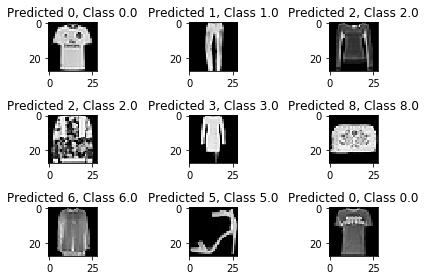

In [18]:
correct = np.where(predicted_classes==test_y)[0]
print( "Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct], test_y[correct]))
    plt.tight_layout()

Found 750 incorrect labels


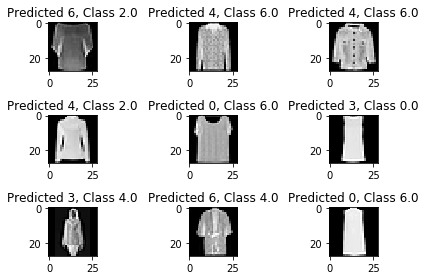

In [19]:
incorrect = np.where(predicted_classes!=test_y)[0]
print( "Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect], test_y[incorrect]))
    plt.tight_layout()